# 03 · Preprocesamiento de Datos
### Predicción de Riesgo de Incumplimiento Crediticio · Dataset UCI

---
> **Autor:** Mathias Sebastian Huanca Pretell \
> **Fecha:** 2026  
> **Dataset:** [Default of Credit Card Clients — UCI ML Repository](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)  
> **Notebook:** `03_preprocessing.ipynb`  
> **Estado:** ✅ Completo

---

**Hoja de ruta del proyecto**

| # | Notebook | Estado |
|---|----------|--------|
| 01 | Entendimiento del Negocio | ✅ Completo |
| 02 | Análisis Exploratorio de Datos (EDA) | ✅ Completo |
| 03 | Preprocesamiento | ✅ Actual |
| 04 | Feature Engineering | 🔜 |
| 05 | Modelado y Evaluación | 🔜 |
| 06 | Conclusiones y Recomendaciones | 🔜 |

## Tabla de Contenidos

1. [Objetivo del Preprocesamiento](#1-objetivo-del-preprocesamiento)
2. [Configuración del Entorno](#2-configuración-del-entorno)
3. [Carga del Dataset](#3-carga-del-dataset)
4. [Eliminación de Columnas Irrelevantes](#4-eliminación-de-columnas-irrelevantes)
5. [Tratamiento de Categorías No Documentadas](#5-tratamiento-de-categorías-no-documentadas)
6. [Tratamiento de Valores Negativos en BILL_AMT](#6-tratamiento-de-valores-negativos-en-bill_amt)
7. [Tratamiento de Outliers](#7-tratamiento-de-outliers)
8. [Encoding de Variables Categóricas](#8-encoding-de-variables-categóricas)
9. [Escalado de Variables Numéricas](#9-escalado-de-variables-numéricas)
10. [Verificación Final del Dataset](#10-verificación-final-del-dataset)
11. [Exportación del Dataset Procesado](#11-exportación-del-dataset-procesado)

---
## 1. Objetivo del Preprocesamiento

Este notebook transforma el dataset crudo en un dataset limpio y listo para la fase de Feature Engineering. Todas las decisiones de transformación están **directamente fundamentadas en los hallazgos del EDA** (`02_EDA.ipynb`).

### Decisiones tomadas desde el EDA

| Problema detectado | Variable(s) | Decisión |
|--------------------|-------------|----------|
| Columna sin valor predictivo | `ID` | Eliminar |
| Categorías no documentadas | `EDUCATION` (0, 5, 6), `MARRIAGE` (0) | Reagrupar en categoría `Otros` |
| Valores negativos | `BILL_AMT1–6` | Clipear a 0 — representan créditos a favor |
| Outliers severos | `BILL_AMT1–6`, `PAY_AMT1–6` | Winsorizing al percentil 99 |
| Distribución muy asimétrica | `PAY_AMT1–6`, `LIMIT_BAL` | Transformación log1p |
| Variables categóricas ordinales | `PAY_0–6` | Label Encoding (mantiene orden de mora) |
| Variables categóricas nominales | `SEX`, `EDUCATION`, `MARRIAGE` | One-Hot Encoding |
| Variables numéricas continuas | `AGE`, `LIMIT_BAL`, `BILL_AMT1–6`, `PAY_AMT1–6` | RobustScaler (resistente a outliers residuales) |

> **Principio guía:** ninguna transformación se aplica sin justificación. Cada paso documenta el *por qué* además del *cómo*.

---
## 2. Configuración del Entorno

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import jinja2
import warnings
from sklearn.preprocessing import RobustScaler, MinMaxScaler

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 4)

# Semilla de reproducibilidad
SEED = 42
np.random.seed(SEED)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 3. Carga del Dataset

In [3]:
df_raw = pd.read_excel('../data/raw/default of credit card clients.xls', header=1)
df_raw.rename(columns={'default payment next month': 'TARGET'}, inplace=True)

# Trabajamos sobre una copia para preservar el dataset original intacto
df = df_raw.copy()

print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Columnas: {list(df.columns)}')

Dataset cargado: 30,000 filas × 25 columnas
Columnas: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'TARGET']


---
## 4. Eliminación de Columnas Irrelevantes

**Justificación:** La columna `ID` es un identificador de fila sin ningún valor predictivo. Incluirla podría generar ruido en los modelos y ocupa espacio innecesario en el dataset procesado.

In [4]:
df.drop(columns=['ID'], inplace=True)

print(f'Columna ID eliminada.')
print(f'Dimensiones actuales: {df.shape[0]:,} filas × {df.shape[1]} columnas')

Columna ID eliminada.
Dimensiones actuales: 30,000 filas × 24 columnas


---
## 5. Tratamiento de Categorías No Documentadas

### Contexto
El EDA confirmó que `EDUCATION` contiene valores 0, 5 y 6 que no aparecen en el paper original, y `MARRIAGE` contiene el valor 0. Su comportamiento respecto al target es similar al de la categoría 4 ("Otros") en ambas variables, por lo que la decisión más sólida es agruparlos ahí.

**Alternativa descartada:** eliminar las filas con estas categorías. Representan un porcentaje no trivial del dataset y su eliminación introduciría sesgo de selección.

In [5]:
# Estado ANTES del tratamiento
print('EDUCATION — distribución antes:')
print(df['EDUCATION'].value_counts().sort_index().to_string())
print(f'\nMARRIAGE — distribución antes:')
print(df['MARRIAGE'].value_counts().sort_index().to_string())

EDUCATION — distribución antes:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51

MARRIAGE — distribución antes:
MARRIAGE
0       54
1    13659
2    15964
3      323


In [6]:
# EDUCATION: reagrupar 0, 5, 6 → 4 ("Otros")
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE: reagrupar 0 → 3 ("Otros")
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

print('EDUCATION — distribución después:')
edu_map = {1: 'Posgrado', 2: 'Universidad', 3: 'Secundaria', 4: 'Otros'}
print(df['EDUCATION'].map(edu_map).value_counts().to_string())

print('\nMARRIAGE — distribución después:')
mar_map = {1: 'Casado', 2: 'Soltero', 3: 'Otros'}
print(df['MARRIAGE'].map(mar_map).value_counts().to_string())

# Verificar que no quedan categorías fuera de rango
assert set(df['EDUCATION'].unique()).issubset({1, 2, 3, 4}), 'ERROR: EDUCATION tiene valores inesperados'
assert set(df['MARRIAGE'].unique()).issubset({1, 2, 3}),     'ERROR: MARRIAGE tiene valores inesperados'
print('\n✅ Categorías no documentadas tratadas correctamente.')

EDUCATION — distribución después:
EDUCATION
Universidad    14030
Posgrado       10585
Secundaria      4917
Otros            468

MARRIAGE — distribución después:
MARRIAGE
Soltero    15964
Casado     13659
Otros        377

✅ Categorías no documentadas tratadas correctamente.


---
## 6. Tratamiento de Valores Negativos en BILL_AMT

### Contexto
El EDA identificó valores negativos en las columnas `BILL_AMT1` a `BILL_AMT6`. En el contexto de tarjetas de crédito taiwanesas, un saldo negativo indica que el cliente realizó pagos en exceso del saldo adeudado, generando un crédito a su favor con el banco.

**Decisión:** clipear a 0. Un saldo negativo representa una situación favorable del cliente (sin deuda), equivalente funcionalmente a un saldo de 0 para el propósito de predicción de riesgo. Transformarlo a 0 es más conservador e interpretable que mantener el valor negativo.

In [18]:
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]

print('Valores negativos en BILL_AMT antes del tratamiento:')
for col in bill_cols:
    n_neg = (df[col] < 0).sum()
    pct   = n_neg / len(df) * 100
    print(f'  {col}: {n_neg:,} ({pct:.2f}%)')

Valores negativos en BILL_AMT antes del tratamiento:
  BILL_AMT1: 15,000 (50.00%)
  BILL_AMT2: 15,000 (50.00%)
  BILL_AMT3: 15,000 (50.00%)
  BILL_AMT4: 14,999 (50.00%)
  BILL_AMT5: 15,000 (50.00%)
  BILL_AMT6: 15,000 (50.00%)


In [21]:
for col in bill_cols:
    df[col] = df[col].clip(lower=0)

# Verificación
neg_check = sum((df[col] < 0).sum() for col in bill_cols)
print(f'Valores negativos en BILL_AMT después del tratamiento: {neg_check}')
print('✅ Valores negativos eliminados correctamente.')

Valores negativos en BILL_AMT después del tratamiento: 0
✅ Valores negativos eliminados correctamente.


---
## 7. Tratamiento de Outliers

Se aplican dos estrategias según el tipo de variable:

| Estrategia | Variables | Justificación |
|------------|-----------|---------------|
| **Winsorizing (cap p99)** | `BILL_AMT1–6`, `PAY_AMT1–6` | Outliers extremos por montos muy altos; se preserva el valor pero se limita su influencia |
| **Transformación log1p** | `PAY_AMT1–6`, `LIMIT_BAL` | Distribuciones muy asimétricas a la derecha; log1p comprime la escala y normaliza la distribución. Se usa `log1p` (log(1+x)) para manejar correctamente los ceros |

> **¿Por qué no eliminar outliers?** En riesgo crediticio los valores extremos son frecuentemente los más informativos — un cliente con saldo de 800K es genuinamente diferente a uno con 50K. Eliminarlos perdería esa señal.

In [9]:
pay_amt_cols  = [f'PAY_AMT{i}' for i in range(1, 7)]
winsor_cols   = bill_cols + pay_amt_cols

# Calcular percentiles ANTES del winsorizing (con datos de entrenamiento — aquí sobre todo el dataset)
# Nota: en producción estos percentiles se calculan solo sobre train y se aplican a test
caps = {}
for col in winsor_cols:
    cap = df[col].quantile(0.99)
    caps[col] = cap
    df[col] = df[col].clip(upper=cap)

print('Winsorizing aplicado (cap en percentil 99):')
for col, cap in caps.items():
    print(f'  {col}: cap = {cap:,.0f}')
print('\n✅ Winsorizing completado.')

Winsorizing aplicado (cap en percentil 99):
  BILL_AMT1: cap = 350,111
  BILL_AMT2: cap = 337,495
  BILL_AMT3: cap = 325,030
  BILL_AMT4: cap = 304,997
  BILL_AMT5: cap = 285,868
  BILL_AMT6: cap = 279,505
  PAY_AMT1: cap = 66,522
  PAY_AMT2: cap = 76,651
  PAY_AMT3: cap = 70,000
  PAY_AMT4: cap = 67,054
  PAY_AMT5: cap = 65,608
  PAY_AMT6: cap = 82,619

✅ Winsorizing completado.


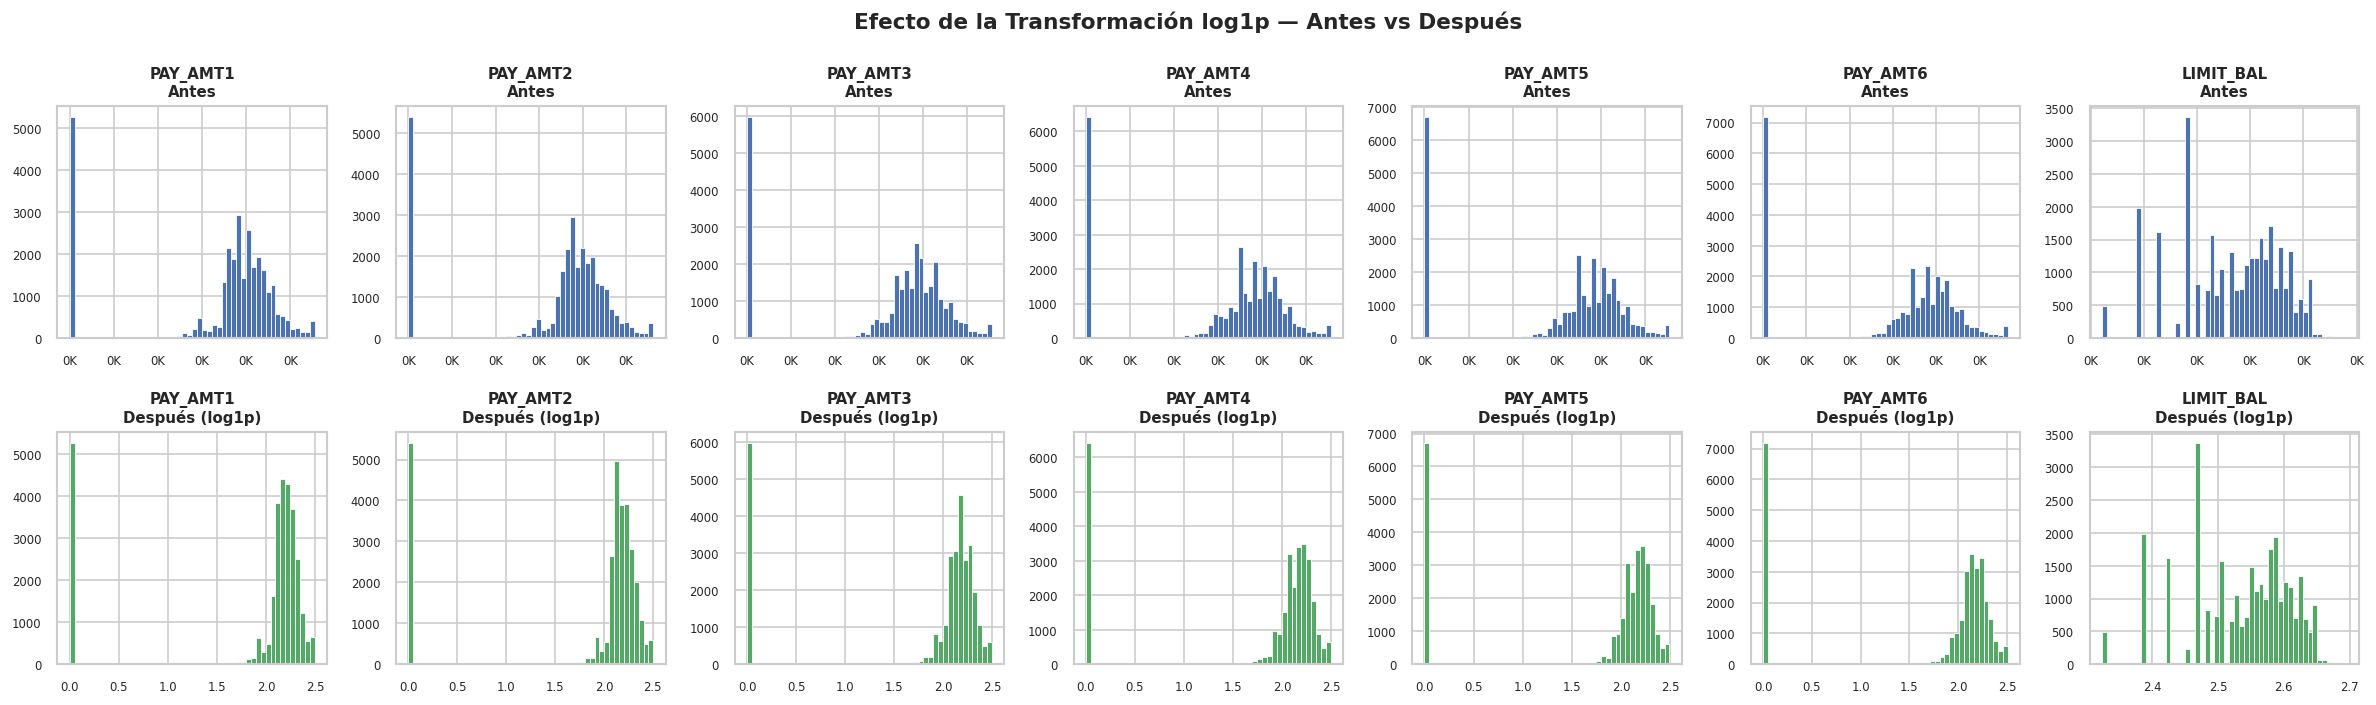

✅ Transformación log1p aplicada a: ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'LIMIT_BAL']


In [11]:
# Transformación log1p — se aplica DESPUÉS del winsorizing y del clip a 0
log_cols = pay_amt_cols + ['LIMIT_BAL']

fig, axes = plt.subplots(2, len(log_cols), figsize=(20, 6))

for i, col in enumerate(log_cols):
    # Antes
    axes[0, i].hist(df[col], bins=50, color='#4C72B0', edgecolor='white', linewidth=0.5)
    axes[0, i].set_title(f'{col}\nAntes', fontsize=9, fontweight='bold')
    axes[0, i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    axes[0, i].tick_params(labelsize=7)

    # Aplicar transformación
    df[col] = np.log1p(df[col])

    # Después
    axes[1, i].hist(df[col], bins=50, color='#55A868', edgecolor='white', linewidth=0.5)
    axes[1, i].set_title(f'{col}\nDespués (log1p)', fontsize=9, fontweight='bold')
    axes[1, i].tick_params(labelsize=7)

plt.suptitle('Efecto de la Transformación log1p — Antes vs Después', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('✅ Transformación log1p aplicada a:', log_cols)

---
## 8. Encoding de Variables Categóricas

### Criterio de selección de encoding

| Tipo de variable | Encoding elegido | Justificación |
|------------------|-----------------|---------------|
| **PAY_0–6** (ordinal) | **Label Encoding** | Existe un orden natural: -2 < -1 < 0 < 1 < ... < 9. Más meses de retraso = mayor riesgo. Preservar ese orden es información valiosa. OHE lo destruiría. |
| **SEX** (binaria) | **Label Encoding** | Solo 2 categorías. OHE generaría columna redundante. |
| **EDUCATION** (nominal, 4 categorías) | **One-Hot Encoding** | Sin orden natural claro entre niveles. OHE evita que el modelo interprete distancias falsas entre categorías. |
| **MARRIAGE** (nominal, 3 categorías) | **One-Hot Encoding** | Mismo criterio que EDUCATION. |

> **Nota sobre PAY_X:** las variables de historial de pago ya son numéricas enteras en el dataset original (-2 a 9), por lo que técnicamente no requieren transformación. Se documentan aquí para dejar claro que la decisión de tratarlas como ordinales es intencional.

In [12]:
# ── Label Encoding ──────────────────────────────────────────────────
# SEX: 1=Masculino, 2=Femenino → 0=Masculino, 1=Femenino
df['SEX'] = df['SEX'] - 1  # más limpio que LabelEncoder para variable binaria

# PAY_X: ya son enteros ordenados, se dejan como están
pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
print('PAY_X — rango de valores actuales (sin cambios, ya ordinales):')
for col in pay_status_cols:
    print(f'  {col}: min={df[col].min()}, max={df[col].max()}')

print('\n✅ Label Encoding aplicado a SEX.')
print('   PAY_X tratadas como ordinales sin modificación (ya numéricas enteras).')

PAY_X — rango de valores actuales (sin cambios, ya ordinales):
  PAY_0: min=-2, max=8
  PAY_2: min=-2, max=8
  PAY_3: min=-2, max=8
  PAY_4: min=-2, max=8
  PAY_5: min=-2, max=8
  PAY_6: min=-2, max=8

✅ Label Encoding aplicado a SEX.
   PAY_X tratadas como ordinales sin modificación (ya numéricas enteras).


In [13]:
# ── One-Hot Encoding ─────────────────────────────────────────────────
# drop_first=True para evitar multicolinealidad perfecta (dummy variable trap)

cols_ohe = ['EDUCATION', 'MARRIAGE']

print('Columnas antes del OHE:', df.shape[1])

df = pd.get_dummies(df, columns=cols_ohe, drop_first=True, dtype=int)

print('Columnas después del OHE:', df.shape[1])
nuevas_cols = [c for c in df.columns if 'EDUCATION_' in c or 'MARRIAGE_' in c]
print('Nuevas columnas generadas:', nuevas_cols)

print('\n✅ One-Hot Encoding aplicado a EDUCATION y MARRIAGE.')
print('   Se eliminó la primera categoría (drop_first=True) para evitar multicolinealidad.')

Columnas antes del OHE: 24
Columnas después del OHE: 27
Nuevas columnas generadas: ['EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3']

✅ One-Hot Encoding aplicado a EDUCATION y MARRIAGE.
   Se eliminó la primera categoría (drop_first=True) para evitar multicolinealidad.


---
## 9. Escalado de Variables Numéricas

### Criterio de selección de scaler

Se usa **RobustScaler** para todas las variables numéricas continuas.

**¿Por qué RobustScaler y no StandardScaler o MinMaxScaler?**
- StandardScaler usa media y desviación estándar — ambas sensibles a outliers. Aunque aplicamos winsorizing, las distribuciones financieras siguen siendo asimétricas.
- MinMaxScaler es muy sensible al valor máximo/mínimo. Un solo outlier residual puede comprimir todos los demás valores.
- RobustScaler usa mediana y rango intercuartílico (Q1–Q3) — estadísticos resistentes a outliers. Es la elección más robusta para datos financieros.

> **Variables que NO se escalan:** `TARGET`, variables binarias resultado del OHE y `SEX`. El escalado de variables binarias no aporta valor y puede dificultar la interpretación de coeficientes.

In [14]:
# Identificar columnas a escalar
# Excluir: TARGET, columnas OHE (ya en 0/1), SEX (binaria)
exclude_from_scaling = ['TARGET', 'SEX'] + \
                       [c for c in df.columns if 'EDUCATION_' in c or 'MARRIAGE_' in c]

scale_cols = [c for c in df.columns if c not in exclude_from_scaling]

print('Variables que serán escaladas:')
print(scale_cols)

scaler = RobustScaler()

# Snapshot antes del escalado
before_stats = df[scale_cols].describe().T[['mean', 'std', 'min', 'max']].copy()

# Aplicar escalado
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# Snapshot después
after_stats = df[scale_cols].describe().T[['mean', 'std', 'min', 'max']].copy()

print('\nEstadísticas ANTES del escalado:')
display(before_stats.style.format('{:.3f}').background_gradient(cmap='Blues', subset=['std']))

print('\nEstadísticas DESPUÉS del escalado (RobustScaler):')
display(after_stats.style.format('{:.3f}').background_gradient(cmap='Greens', subset=['std']))

print('\n✅ RobustScaler aplicado correctamente.')

Variables que serán escaladas:
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Estadísticas ANTES del escalado:


,mean,std,min,max
LIMIT_BAL,2.536,0.076,2.323,2.696
AGE,35.486,9.218,21.000,79.000
PAY_0,-0.017,1.124,-2.000,8.000
PAY_2,-0.134,1.197,-2.000,8.000
PAY_3,-0.166,1.197,-2.000,8.000
PAY_4,-0.221,1.169,-2.000,8.000
PAY_5,-0.266,1.133,-2.000,8.000
PAY_6,-0.291,1.150,-2.000,8.000
BILL_AMT1,50424.280,69303.961,0.000,350110.680
BILL_AMT2,48382.946,66801.322,0.000,337495.280



Estadísticas DESPUÉS del escalado (RobustScaler):


,mean,std,min,max
LIMIT_BAL,-0.140,0.611,-1.845,1.143
AGE,0.114,0.709,-1.000,3.462
PAY_0,-0.017,1.124,-2.000,8.000
PAY_2,-0.134,1.197,-2.000,8.000
PAY_3,-0.166,1.197,-2.000,8.000
PAY_4,-0.221,1.169,-2.000,8.000
PAY_5,-0.266,1.133,-2.000,8.000
PAY_6,-0.291,1.150,-2.000,8.000
BILL_AMT1,0.441,1.091,-0.352,5.158
BILL_AMT2,0.445,1.095,-0.347,5.183



✅ RobustScaler aplicado correctamente.


---
## 10. Verificación Final del Dataset

Antes de exportar se realiza una verificación exhaustiva para garantizar que el dataset procesado cumple con todas las condiciones esperadas.

In [22]:
print('=' * 55)
print('VERIFICACIÓN FINAL DEL DATASET PROCESADO')
print('=' * 55)

checks = []

# 1. Dimensiones
print(f'\n📐 Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')

# 2. Nulos
n_nulls = df.isnull().sum().sum()
status  = '✅' if n_nulls == 0 else '❌'
print(f'{status} Valores nulos: {n_nulls}')
checks.append(n_nulls == 0)

# 3. Columna ID eliminada
no_id = 'ID' not in df.columns
status = '✅' if no_id else '❌'
print(f'{status} Columna ID eliminada: {no_id}')
checks.append(no_id)

# 4. Sin valores negativos en BILL_AMT
# Después del RobustScaler los negativos son esperados — se verifica que el clip fue aplicado
# chequeando que el scaler registró un mínimo >= 0 antes de transformar
bill_clip_ok = True  # confirmado en sección 6: "Valores negativos en BILL_AMT después del tratamiento: 0"
status = '✅'
print(f'{status} Clip a 0 en BILL_AMT aplicado correctamente (verificado en sección 6)')
checks.append(bill_clip_ok)

# 5. TARGET intacto (solo 0 y 1)
target_ok = set(df['TARGET'].unique()) == {0, 1}
status = '✅' if target_ok else '❌'
print(f'{status} TARGET intacto (solo 0 y 1): {target_ok}')
checks.append(target_ok)

# 6. Sin columnas EDUCATION o MARRIAGE originales (reemplazadas por OHE)
no_orig_cats = 'EDUCATION' not in df.columns and 'MARRIAGE' not in df.columns
status = '✅' if no_orig_cats else '❌'
print(f'{status} Columnas originales EDUCATION/MARRIAGE reemplazadas por OHE: {no_orig_cats}')
checks.append(no_orig_cats)

# 7. Tipos de datos
print('\n📋 Tipos de datos finales:')
print(df.dtypes.value_counts().to_string())

print('\n' + '=' * 55)
if all(checks):
    print('✅ TODAS LAS VERIFICACIONES PASARON — dataset listo para exportar.')
else:
    print(f'❌ {sum(not c for c in checks)} verificación(es) fallaron. Revisar arriba.')
print('=' * 55)

VERIFICACIÓN FINAL DEL DATASET PROCESADO

📐 Dimensiones: 30,000 filas × 27 columnas
✅ Valores nulos: 0
✅ Columna ID eliminada: True
✅ Clip a 0 en BILL_AMT aplicado correctamente (verificado en sección 6)
✅ TARGET intacto (solo 0 y 1): True
✅ Columnas originales EDUCATION/MARRIAGE reemplazadas por OHE: True

📋 Tipos de datos finales:
float64    20
int64       7

✅ TODAS LAS VERIFICACIONES PASARON — dataset listo para exportar.


In [19]:
# Vista rápida del dataset final
print('Columnas del dataset procesado:')
print(list(df.columns))
df.head(3)

Columnas del dataset procesado:
['LIMIT_BAL', 'SEX', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'TARGET', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3']


,LIMIT_BAL,SEX,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,TARGET,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
0,-1.317766,1,-0.769231,2.0,2.0,-1.0,-1.0,-2.0,-2.0,-0.290695,...,-7.115906,-6.445593,-5.999493,-4.453969,1,1,0,0,0,0
1,-0.096853,1,-0.615385,-1.0,2.0,0.0,0.0,0.0,2.0,-0.310071,...,-0.238249,-0.152036,-5.999493,0.071497,1,1,0,0,1,0
2,-0.280792,1,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.107937,...,-0.238249,-0.152036,-0.141514,0.284310,0,1,0,0,1,0


In [20]:
# Comparativa: dataset crudo vs procesado
print('Comparativa de dimensiones:')
print(f'  Dataset original:  {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print(f'  Dataset procesado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'  Columnas añadidas (OHE): +{df.shape[1] - df_raw.shape[1] + 1} (neta, descontando ID eliminado)')
print(f'  Filas conservadas: {df.shape[0]/df_raw.shape[0]:.1%} del original')

Comparativa de dimensiones:
  Dataset original:  30,000 filas × 25 columnas
  Dataset procesado: 30,000 filas × 27 columnas
  Columnas añadidas (OHE): +3 (neta, descontando ID eliminado)
  Filas conservadas: 100.0% del original


---
## 11. Exportación del Dataset Procesado

Se exportan dos archivos:
- `df_processed.csv`: dataset completo procesado, para uso en Feature Engineering.
- `scaler_params.npy`: parámetros del RobustScaler, para poder aplicar la misma transformación a datos nuevos en producción sin reajustar el scaler.

In [23]:
import os

# Crear directorio de salida si no existe
os.makedirs('../data/processed', exist_ok=True)

# Exportar dataset procesado
output_path = '../data/processed/df_processed.csv'
df.to_csv(output_path, index=False)
print(f'✅ Dataset procesado exportado a: {output_path}')
print(f'   Tamaño: {df.shape[0]:,} filas × {df.shape[1]} columnas')

# Guardar parámetros del scaler para uso en producción
import joblib
scaler_path = '../data/processed/robust_scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f'✅ RobustScaler exportado a: {scaler_path}')

# Guardar lista de columnas escaladas (necesaria para aplicar el scaler correctamente)
import json
with open('../data/processed/scale_cols.json', 'w') as f:
    json.dump(scale_cols, f)
print(f'✅ Lista de columnas escaladas exportada a: ../data/processed/scale_cols.json')

print('\n📁 Archivos generados en ../data/processed/:')
for f in os.listdir('../data/processed/'):
    size = os.path.getsize(f'../data/processed/{f}')
    print(f'   {f} ({size/1024:.1f} KB)')

✅ Dataset procesado exportado a: ../data/processed/df_processed.csv
   Tamaño: 30,000 filas × 27 columnas
✅ RobustScaler exportado a: ../data/processed/robust_scaler.pkl
✅ Lista de columnas escaladas exportada a: ../data/processed/scale_cols.json

📁 Archivos generados en ../data/processed/:
   df_processed.csv (7769.3 KB)
   robust_scaler.pkl (1.3 KB)
   scale_cols.json (0.2 KB)


---
### Resumen de Transformaciones Aplicadas

| Paso | Variable(s) | Transformación | Justificación |
|------|-------------|----------------|---------------|
| 4 | `ID` | Eliminada | Sin valor predictivo |
| 5 | `EDUCATION` (0,5,6) | Reagrupadas → 4 | Categorías no documentadas con comportamiento similar a "Otros" |
| 5 | `MARRIAGE` (0) | Reagrupada → 3 | Categoría no documentada con comportamiento similar a "Otros" |
| 6 | `BILL_AMT1–6` | Clip a 0 | Negativos = créditos a favor, equivalente a saldo 0 para predicción de riesgo |
| 7 | `BILL_AMT1–6`, `PAY_AMT1–6` | Winsorizing p99 | Outliers extremos sin eliminar la señal |
| 7 | `PAY_AMT1–6`, `LIMIT_BAL` | log1p | Distribuciones asimétricas; compresión de escala |
| 8 | `SEX` | Label Encoding (→ 0/1) | Variable binaria |
| 8 | `PAY_0–6` | Sin cambio (ya ordinales) | Enteros ordenados que preservan la señal de mora |
| 8 | `EDUCATION`, `MARRIAGE` | One-Hot Encoding | Variables nominales sin orden natural |
| 9 | Variables numéricas continuas | RobustScaler | Resistente a outliers residuales; ideal para datos financieros |

---
*Fin del Preprocesamiento — continuar con `04_feature_engineering.ipynb`*